# ECE1508 - Course Project
##  Federated Learning Architectures for WiFi-Based Human Activity Recognition

## 1. Setup & Imports

In [1]:
import numpy as np
import glob
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision.models import resnet50, densenet121
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Data Loading & Preprocessing

Each sample is a CSI matrix of shape 1 × 250 × 90 (channels × time steps × subcarriers).

Data are min-max normalised to [0, 1].

There are 7 activity classes: lying down, falling, walking, running, sitting down, standing up, and background.

In [2]:
def load_UT_HAR(root_dir):

    data_files = glob.glob(root_dir + '/data/*.csv')
    label_files = glob.glob(root_dir + '/label/*.csv')
    expected = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    wifi = {}

    for path in data_files:
        key = path.replace('\\', '/').split('/')[-1].split('.')[0]
        if key not in expected:
            continue
        data = np.load(path, allow_pickle=True)
        data = data.reshape(len(data), 1, 250, 90)
        data = (data - data.min()) / (data.max() - data.min())
        wifi[key] = torch.tensor(data, dtype=torch.float32)

    for path in label_files:
        key = path.replace('\\', '/').split('/')[-1].split('.')[0]
        if key not in expected:
            continue
        labels = np.load(path, allow_pickle=True)
        wifi[key] = torch.tensor(labels, dtype=torch.int64)

    return wifi

In [3]:
ROOT = 'UT_HAR'
wifi = load_UT_HAR(ROOT)

X_train, y_train = wifi['X_train'], wifi['y_train']
X_test, y_test = wifi['X_test'], wifi['y_test']

NUM_CLASSES = int(y_train.max().item()) + 1

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


print(f'X_train: {X_train.shape} y_train: {y_train.shape}')
print(f'X_test: {X_test.shape} y_test: {y_test.shape}')
print(f'Classes: {NUM_CLASSES} -> {y_train.unique().tolist()}')

X_train: torch.Size([3977, 1, 250, 90]) y_train: torch.Size([3977])
X_test: torch.Size([500, 1, 250, 90]) y_test: torch.Size([500])
Classes: 7 -> [0, 1, 2, 3, 4, 5, 6]


## 3. Model Definitions

### Custom CNN

In [4]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 31 * 11, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

### ResNet-50

In [5]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = resnet50(weights=None)
        self.base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.fc = nn.Linear(self.base.fc.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

### DenseNet-121

In [6]:
class DenseNetModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = densenet121(weights=None)
        self.base.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.classifier = nn.Linear(self.base.classifier.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

In [7]:
MODEL_BUILDERS = {
    'CNN': lambda: CNNModel(NUM_CLASSES),
    'ResNet50': lambda: ResNet50Model(NUM_CLASSES),
    'DenseNet': lambda: DenseNetModel(NUM_CLASSES),
}

MODELS = list(MODEL_BUILDERS.keys())

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print('Model Parameter Counts')
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    print(f'{name} params: {count_params(m)/1e6:.2f} M')

Model Parameter Counts
CNN params: 2.82 M
ResNet50 params: 23.52 M
DenseNet params: 6.95 M


## 4. Utility Functions

In [8]:
# Local training step
def train_local(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)

    return model, total_loss / max(n_batches, 1), train_acc

In [9]:
# Evaluation
@torch.no_grad()
def evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1

In [10]:
# FedAvg aggregation
def fedavg_aggregate(global_model, client_models, weights=None):

    K = len(client_models)
    if weights is None:
        weights = [1.0 / K] * K
    global_sd = global_model.state_dict()
    client_sds = [m.state_dict() for m in client_models]
    for key in global_sd:
        if global_sd[key].dtype.is_floating_point:
            global_sd[key] = sum(w * sd[key] for w, sd in zip(weights, client_sds))
        else:
            global_sd[key] = client_sds[0][key]
    global_model.load_state_dict(global_sd)
    return global_model

In [11]:
# Communication cost
def model_size_M(model):
    return count_params(model) / 1e6

## 5. Client Data Partitioning

The training set is split into K equal IID partitions, one per client.

In [12]:
def iid_partition(dataset, K, batch_size=64):

    n = len(dataset)
    indices = torch.randperm(n).tolist()
    splits = np.array_split(indices, K)
    loaders = []
    for idx in splits:
        subset = Subset(dataset, idx.tolist())
        loaders.append(DataLoader(subset, batch_size=batch_size, shuffle=True))
    return loaders

## 6. Centralized FedAvg

Protocol per round:
1. Broadcast global model to all K clients.
2. Each client trains locally for E epochs.
3. Server collects and averages all client models.

Communication cost per round: 2 × K × |θ| (K uploads + K downloads).

In [13]:
def run_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_dataset, K, batch_size)
    global_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(global_model)
    comm_per_round = 2 * K * params

    round_local_train_acc = []
    round_global_train_acc = []
    round_acc = []
    round_f1 = []

    for t in range(1, T + 1):
        client_models = []
        client_train_accs = []
        for loader in client_loaders:
            client = copy.deepcopy(global_model)
            client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
            client_models.append(client)
            client_train_accs.append(train_acc)

        global_model = fedavg_aggregate(global_model, client_models)
        local_avg_train_acc = sum(client_train_accs) / len(client_train_accs)
        global_train_acc, _ = evaluate(global_model, train_loader)
        acc, f1 = evaluate(global_model, test_loader)

        round_local_train_acc.append(local_avg_train_acc)
        round_global_train_acc.append(global_train_acc)
        round_acc.append(acc)
        round_f1.append(f1)
        print(
            f'Round {t:2d}/{T}  '
            f'LocalAvgTrain={local_avg_train_acc:.2f}%  '
            f'GlobalTrain={global_train_acc:.2f}%  '
            f'GlobalTest={acc:.2f}%  '
            f'F1={f1:.4f}'
        )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_local_train_acc': round_local_train_acc,
        'round_global_train_acc': round_global_train_acc,
        'round_acc': round_acc,
        'round_f1': round_f1,
        'final_acc': round_acc[-1],
        'final_f1': round_f1[-1],
        'comm_M': total_comm,
        'model': global_model
    }

## 7. Run Experiments

**Experiment Configuration**

K: Total number of clients

T: Number of global communication rounds

E: Local training epochs per round per client

batch_size: Mini-batch size during local training

lr: Learning rate for Adam optimiser

In [14]:
K = 10
T = 10
E = 5
batch_size = 64
lr = 1e-3

results = {}

print('Experiment Configuration')
print(f'K={K}, T={T}, E={E}, batch_size={batch_size}, lr={lr}')

Experiment Configuration
K=10, T=10, E=5, batch_size=64, lr=0.001


### Model Training

In [15]:
print('Centralized FL')

for model_name in MODELS:
    results.setdefault(model_name, {})
    print('-' * 60)
    print(f'Model: {model_name}')
    print()
    results[model_name]['FedAvg'] = run_fedavg(model_name, K=K, T=T, E=E, batch_size=batch_size, lr=lr)

Centralized FL
------------------------------------------------------------
Model: CNN

Round  1/10  LocalAvgTrain=34.27%  GlobalTrain=29.44%  GlobalTest=29.80%  F1=0.0698
Round  2/10  LocalAvgTrain=49.91%  GlobalTrain=50.04%  GlobalTest=49.40%  F1=0.3436
Round  3/10  LocalAvgTrain=58.38%  GlobalTrain=57.58%  GlobalTest=54.80%  F1=0.4548
Round  4/10  LocalAvgTrain=65.65%  GlobalTrain=66.11%  GlobalTest=63.20%  F1=0.5752
Round  5/10  LocalAvgTrain=72.47%  GlobalTrain=71.94%  GlobalTest=68.40%  F1=0.6275
Round  6/10  LocalAvgTrain=76.92%  GlobalTrain=76.14%  GlobalTest=72.00%  F1=0.6573
Round  7/10  LocalAvgTrain=82.02%  GlobalTrain=80.04%  GlobalTest=76.20%  F1=0.7162
Round  8/10  LocalAvgTrain=85.49%  GlobalTrain=83.38%  GlobalTest=78.80%  F1=0.7492
Round  9/10  LocalAvgTrain=88.59%  GlobalTrain=85.79%  GlobalTest=80.20%  F1=0.7640
Round 10/10  LocalAvgTrain=89.79%  GlobalTrain=87.13%  GlobalTest=83.00%  F1=0.7958
Total comm cost: 564.5 M params
----------------------------------------

## 8. Results & Visualisation

### Summary table

In [16]:
print('Final Results Summary')
print(f"{'Model':<12} {'Acc (%)':>8} {'Macro-F1':>10} {'Comm (M params)':>18}")
for model_name in MODELS:
    r = results[model_name]['FedAvg']
    print(f"{model_name:<12} {r['final_acc']:>8.2f} {r['final_f1']:>10.4f} {r['comm_M']:>18.1f}")

Final Results Summary
Model         Acc (%)   Macro-F1    Comm (M params)
CNN             83.00     0.7958              564.5
ResNet50        93.40     0.9140             4703.2
DenseNet        93.40     0.9341             1391.0


### Convergence plots: LocalAvgTrain, GlobalTrain, GlobalTest

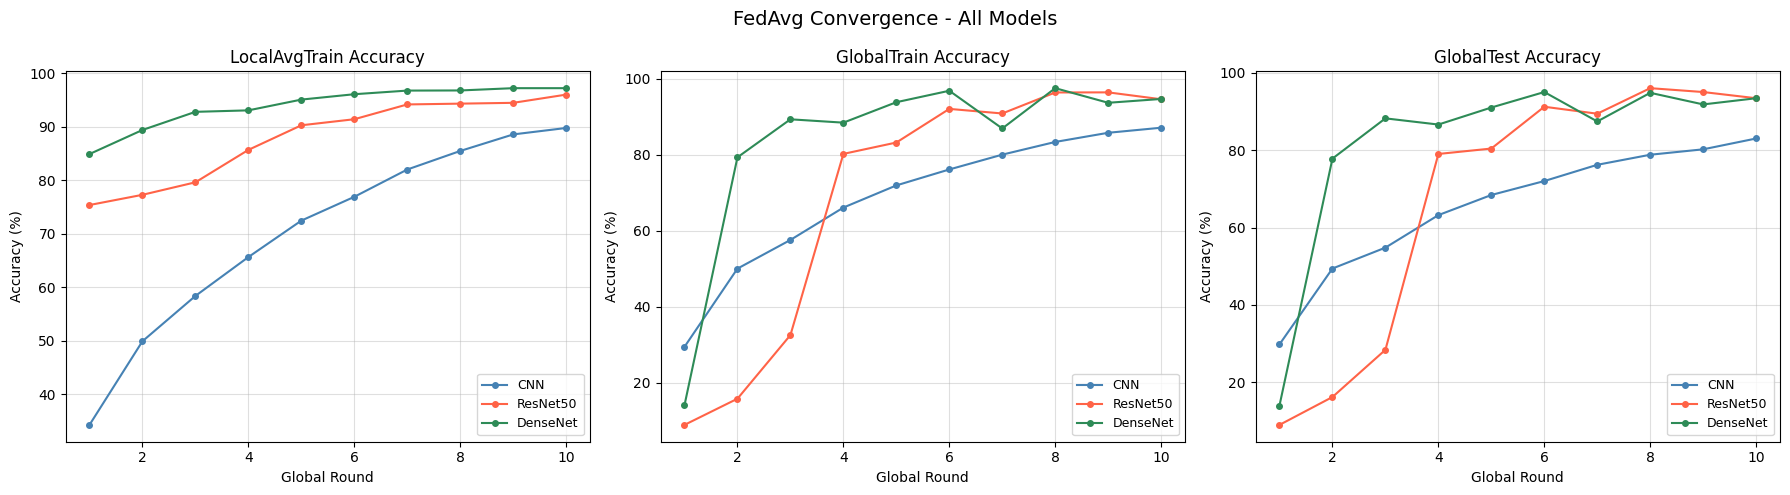

In [17]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'steelblue', 'ResNet50': 'tomato', 'DenseNet': 'seagreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
titles = ['LocalAvgTrain Accuracy', 'GlobalTrain Accuracy', 'GlobalTest Accuracy']
keys = ['round_local_train_acc', 'round_global_train_acc', 'round_acc']

for ax, title, key in zip(axes, titles, keys):
    for model_name in MODELS:
        r = results[model_name]['FedAvg']
        ax.plot(rounds, r[key], color=colors[model_name], marker='o', markersize=4, label=model_name)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle('FedAvg Convergence - All Models', fontsize=14)
plt.tight_layout()
plt.show()

### Macro-F1 convergence

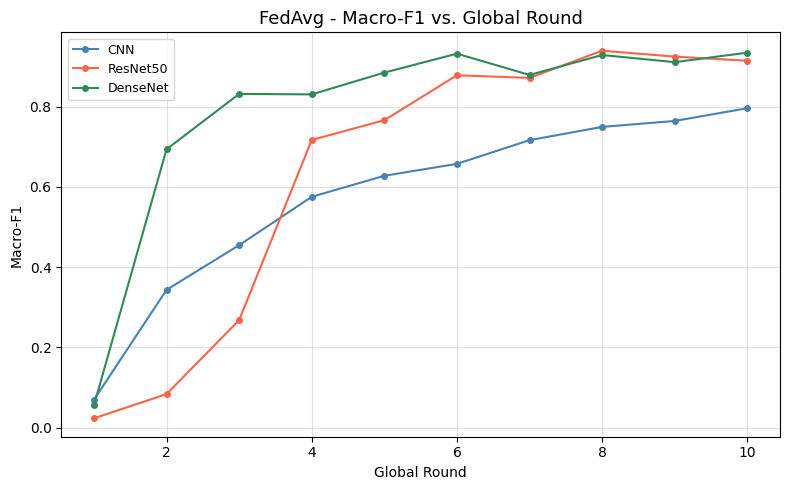

In [18]:
rounds = list(range(1, T + 1))
fig, ax = plt.subplots(figsize=(8, 5))

for model_name in MODELS:
    r = results[model_name]['FedAvg']
    ax.plot(rounds, r['round_f1'], color=colors[model_name], marker='o', markersize=4, label=model_name)

ax.set_title('FedAvg - Macro-F1 vs. Global Round', fontsize=13)
ax.set_xlabel('Global Round')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Bar chart: final accuracy and F1

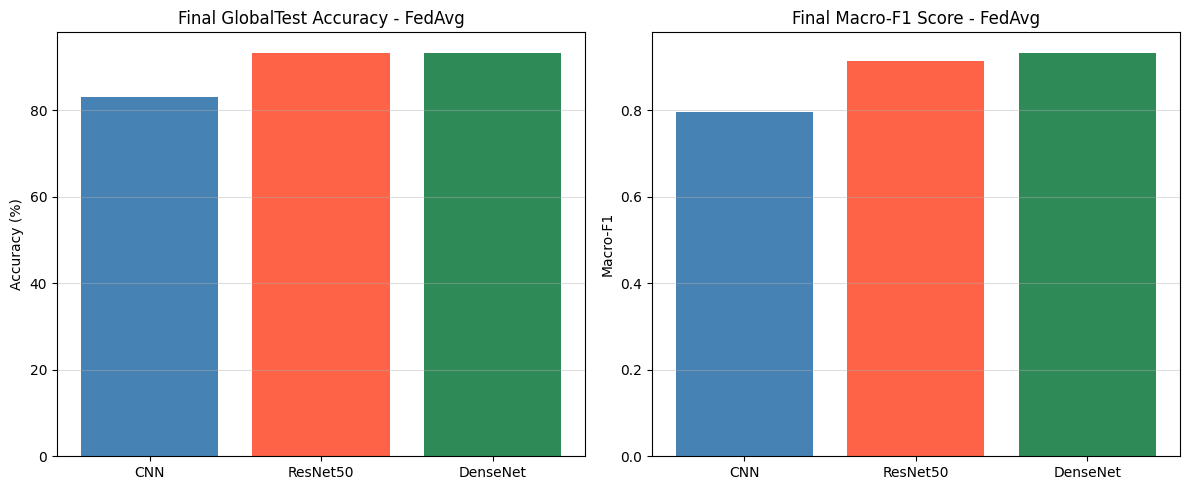

In [19]:
x = np.arange(len(MODELS))
color_list = [colors[m] for m in MODELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

accs = [results[m]['FedAvg']['final_acc'] for m in MODELS]
f1s = [results[m]['FedAvg']['final_f1'] for m in MODELS]

ax1.bar(x, accs, color=color_list)
ax2.bar(x, f1s, color=color_list)

for ax, ylabel, title in [
    (ax1, 'Accuracy (%)', 'Final GlobalTest Accuracy - FedAvg'),
    (ax2, 'Macro-F1', 'Final Macro-F1 Score - FedAvg')
]:
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()